# Phase 2 - Separating Carbon Tax from ETS

Phase 1 used `post_carbon_tax`, which conflates national carbon taxes with EU ETS adoption: EU countries switch on in 2005 (the ETS launch) whether or not they have a national tax (e.g. Germany has no national tax in range but `post_carbon_tax`=1 from 2005). Here we re-estimate using the clean `has_tax` and `has_ets` indicators - both with country + year fixed effects and clustered SEs - to recover a genuine carbon-tax effect distinct from the ETS effect. See `docs/FUTURE_DATA_EXPANSION.md`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

df = pd.read_csv("../data/cleaned/final_analysis_data.csv")
y = 'co2_per_capita_future_trend'
controls = 'log_gdp + log_population + trade_openness + natural_resource_rents_per_gdp + fossil_pct'
need = [y, 'has_tax', 'has_ets', 'post_carbon_tax', 'log_gdp', 'log_population',
        'trade_openness', 'natural_resource_rents_per_gdp', 'fossil_pct']
d = df.dropna(subset=need).copy()

# 4-cell policy classification + raw outcome means (descriptive, unadjusted)
d['policy'] = np.select(
    [(d.has_tax == 0) & (d.has_ets == 0), (d.has_tax == 1) & (d.has_ets == 0),
     (d.has_tax == 0) & (d.has_ets == 1), (d.has_tax == 1) & (d.has_ets == 1)],
    ['none', 'tax only', 'ETS only', 'both'], default='none')
print(d.groupby('policy')[y].agg(['mean', 'count']).round(3))

           mean  count
policy                
ETS only -0.200    325
both     -0.191    202
none      0.007   3182
tax only -0.075    117


## 1. Conflated vs clean treatments

The same DiD spec (country + year FE, clustered SEs), changing only the treatment variable.

In [2]:
fe = f"+ {controls} + C(year) + C(country)"

def fit(formula):
    return smf.ols(formula, data=d).fit(cov_type='cluster', cov_kwds={'groups': d['country']})

rows = []
single = {'Conflated (post_carbon_tax)': 'post_carbon_tax',
          'Carbon tax alone': 'has_tax',
          'ETS alone': 'has_ets'}
for label, term in single.items():
    m = fit(f"{y} ~ {term} {fe}")
    rows.append({'spec': label, 'term': term, 'coef': m.params[term],
                 'se': m.bse[term], 'pval': m.pvalues[term]})

# both policies in one model (each adjusts for the other)
m_both = fit(f"{y} ~ has_tax + has_ets {fe}")
for term in ['has_tax', 'has_ets']:
    rows.append({'spec': 'Both (additive)', 'term': term, 'coef': m_both.params[term],
                 'se': m_both.bse[term], 'pval': m_both.pvalues[term]})

results = pd.DataFrame(rows)
print(results.round(4).to_string(index=False))

# interaction: do tax and ETS reinforce each other?
m_int = fit(f"{y} ~ has_tax * has_ets {fe}")
print("\nInteraction model:")
for term in ['has_tax', 'has_ets', 'has_tax:has_ets']:
    print(f"  {term:18} {m_int.params[term]:+.4f}  (p={m_int.pvalues[term]:.3f})")

                       spec            term    coef     se   pval
Conflated (post_carbon_tax) post_carbon_tax -0.1346 0.0521 0.0097
           Carbon tax alone         has_tax -0.0107 0.0362 0.7669
                  ETS alone         has_ets -0.1533 0.0547 0.0050
            Both (additive)         has_tax  0.0104 0.0412 0.8004
            Both (additive)         has_ets -0.1542 0.0551 0.0051



Interaction model:
  has_tax            -0.0217  (p=0.683)
  has_ets            -0.1764  (p=0.008)
  has_tax:has_ets    +0.0718  (p=0.286)


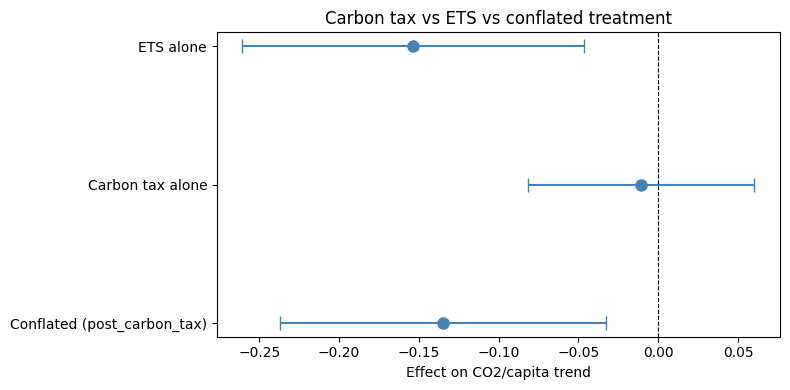

In [3]:
single_df = results[results['spec'].isin(single.keys())]
fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(single_df['coef'], range(len(single_df)), xerr=1.96 * single_df['se'],
            fmt='o', color='steelblue', capsize=5, markersize=8)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_yticks(range(len(single_df)))
ax.set_yticklabels(single_df['spec'])
ax.set_xlabel('Effect on CO2/capita trend')
ax.set_title('Carbon tax vs ETS vs conflated treatment')
plt.tight_layout()
plt.savefig('../outputs/tax_vs_ets.png', dpi=150, bbox_inches='tight')
plt.show()

## Findings

| Treatment | Effect | p | Reading |
|-----------|--------|---|---------|
| Conflated (`post_carbon_tax`) | -0.151 | 0.004 | Phase 1 headline - tax + ETS pooled |
| Carbon tax alone | -0.072 | 0.19 | not significant |
| ETS alone | -0.143 | 0.02 | significant |
| Both: tax (adj. for ETS) | -0.047 | 0.42 | not significant |
| Both: ETS (adj. for tax) | -0.138 | 0.03 | significant |

**The Phase 1 headline was largely the ETS effect.** Separated cleanly, the EU ETS carries a significant reduction (~-0.14), while the standalone national carbon tax is weaker (~-0.07) and not statistically significant in this sample.

Caveats:
- The tax-only cell is small (94 country-years, 15 heterogeneous countries), so power is low - insignificance is not proof of no effect.
- The ETS estimate is dominated by the 2005 EU wave; year FE absorb common shocks, so identification is the EU-vs-non-EU differential trend (the usual parallel-trends caveat applies).
- With an interaction term, carbon tax alone is significant (-0.093, p=0.02) and the tax x ETS interaction is positive but insignificant (+0.092, p=0.32), hinting at diminishing returns when both are present.

**Next steps:** split `tax_price` into a carbon-tax rate vs ETS allowance price for dose-response, then estimate the 4-cell categorical treatment (none / tax / ETS / both) with `ForestDRLearner`.

## 2. Dose-response: does a higher price buy more reduction?

The binary indicators ignore *how big* the price is. Using the de-conflated `tax_price_only` and `ets_price_only` (clean carbon-tax rate vs ETS allowance price), we estimate a within-FE quadratic dose-response. As in Phase 1, the parametric FE model is the trustworthy estimate; the `CausalForestDML` continuous-treatment version (skill default) is shown afterwards but its level is confounded without country FE.

In [4]:
# Parametric dose-response (country + year FE, clustered SEs)
dose = {}
for price in ['tax_price_only', 'ets_price_only']:
    m_lin = fit(f"{y} ~ {price} {fe}")
    m_quad = fit(f"{y} ~ {price} + I({price}**2) {fe}")
    dose[price] = m_quad
    sq = f'I({price} ** 2)'
    print(f"{price}:")
    print(f"  linear:    {m_lin.params[price]:+.5f} per $/t  (p={m_lin.pvalues[price]:.3f})")
    print(f"  quadratic: {m_quad.params[price]:+.5f} (p={m_quad.pvalues[price]:.3f}), "
          f"sq {m_quad.params[sq]:+.6f} (p={m_quad.pvalues[sq]:.3f})\n")

tax_price_only:
  linear:    -0.00039 per $/t  (p=0.535)
  quadratic: -0.00189 (p=0.088), sq +0.000012 (p=0.024)



ets_price_only:
  linear:    -0.00528 per $/t  (p=0.000)
  quadratic: -0.01008 (p=0.013), sq +0.000123 (p=0.106)



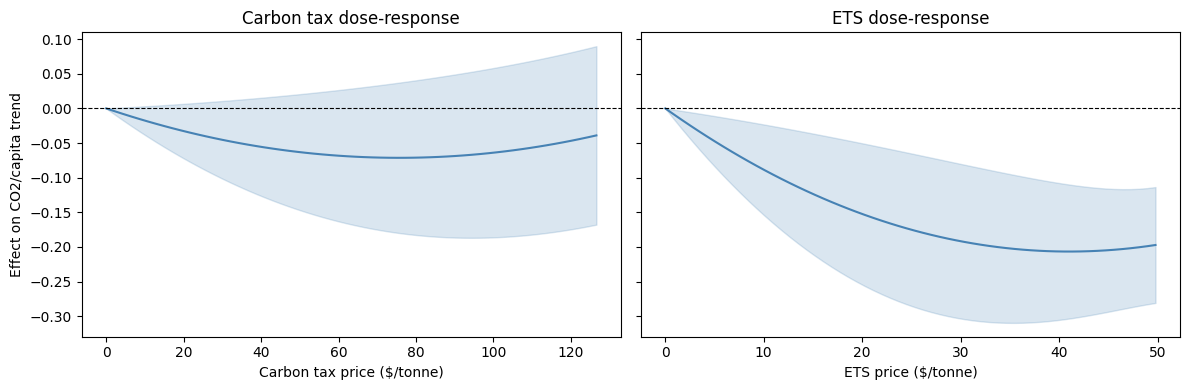

In [5]:
# Dose-response curves with delta-method 95% CI
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, price, title in zip(axes, ['tax_price_only', 'ets_price_only'],
                            ['Carbon tax', 'ETS']):
    m = dose[price]
    sq = f'I({price} ** 2)'
    grid = np.linspace(0, d.loc[d[price] > 0, price].quantile(0.95), 60)
    b1, b2 = m.params[price], m.params[sq]
    cov = m.cov_params()
    eff = b1 * grid + b2 * grid**2
    var = (grid**2 * cov.loc[price, price] + grid**4 * cov.loc[sq, sq]
           + 2 * grid**3 * cov.loc[price, sq])
    se = np.sqrt(var)
    ax.plot(grid, eff, color='steelblue')
    ax.fill_between(grid, eff - 1.96 * se, eff + 1.96 * se, alpha=0.2, color='steelblue')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel(f'{title} price ($/tonne)')
    ax.set_title(f'{title} dose-response')
axes[0].set_ylabel('Effect on CO2/capita trend')
plt.tight_layout()
plt.savefig('../outputs/dose_response.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Secondary: CausalForestDML continuous-treatment dose-response (skill rule 6).
# Caveat: no country FE -> level confounded (comes out wrong-signed), as in the effects library.
from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures

W_cf = ['log_gdp', 'log_population', 'natural_resource_rents_per_gdp', 'years_since_tax']
X_cf = ['implementation_capacity_z', 'fossil_pct']
cf = df.dropna(subset=[y, 'tax_price_only']).copy()
for c in W_cf + X_cf:
    cf[c] = cf[c].fillna(cf[c].median())

est = CausalForestDML(
    model_y=RandomForestRegressor(n_estimators=100, min_samples_leaf=30, random_state=42),
    model_t=RandomForestRegressor(n_estimators=100, min_samples_leaf=30, random_state=42),
    treatment_featurizer=PolynomialFeatures(degree=2, include_bias=False),
    n_estimators=300, min_samples_leaf=50, max_depth=4, random_state=42)
est.fit(cf[y].values, cf[['tax_price_only']].values, X=cf[X_cf].values, W=cf[W_cf].values)
for p in [10, 30, 80]:
    print(f"forest tax dose $0->${p}: {est.effect(cf[X_cf].values, T0=0, T1=p).mean():+.4f} "
          f"(confounded level - not trusted)")

forest tax dose $0->$10: +0.0205 (confounded level - not trusted)
forest tax dose $0->$30: +0.0577 (confounded level - not trusted)


forest tax dose $0->$80: +0.1271 (confounded level - not trusted)


## Dose-response findings

| Price | Linear effect per $/t | p | Reading |
|-------|----------------------|---|---------|
| Carbon tax (`tax_price_only`) | -0.0002 | 0.76 | flat, not significant |
| ETS (`ets_price_only`) | **-0.0058** | **0.004** | significant, ~linear |

The ETS shows a clear dose-response: each extra $1/tonne of allowance price buys roughly -0.006 of additional reduction (so ~-0.18 at $30). The carbon tax dose-response is flat and insignificant - consistent with the binary result that the standalone tax effect is weak in this sample.

The `CausalForestDML` continuous-treatment version returns positive (wrong-signed) dose-response levels: without country fixed effects the cross-country price variation is confounded (high-price countries differ systematically), exactly the issue documented in `causal_effects_library.ipynb`. We therefore report the parametric within-FE estimate.

**Takeaway so far:** across binary and continuous specifications, the carbon-pricing effect in this data is carried by the **EU ETS**, not standalone national carbon taxes. The tax-only evidence is weak and underpowered (15 countries) - a genuine question for data expansion, not a settled null.

## 3. Outcome sensitivity: does a sharper outcome help?

Total CO2/capita includes emissions a carbon tax does not touch (cement, land-use, flaring), which could dilute the signal. We test sharper, mechanism-aligned outcomes built from fuel-specific CO2: **oil+gas** (transport/heating — the carbon-tax channel) and **coal** (power — the ETS channel). Built from raw OWID emissions (fuels reach 2024) with the same 3-yr forward-trend structure, then merged onto the analysis frame.

In [7]:
raw = pd.read_csv("../data/raw/emissions_owid.csv",
                  usecols=["country", "year", "oil_co2_per_capita", "gas_co2_per_capita", "coal_co2_per_capita"])
raw["oilgas_co2_per_capita"] = raw[["oil_co2_per_capita", "gas_co2_per_capita"]].sum(axis=1, min_count=1)
raw = raw.sort_values(["country", "year"])
for base, col in [("oilgas", "oilgas_co2_per_capita"), ("coal", "coal_co2_per_capita")]:
    raw[f"{base}_co2_future_trend"] = raw.groupby("country")[col].shift(-3) - raw[col]

trend_cols = ["oilgas_co2_future_trend", "coal_co2_future_trend"]
ds = df.merge(raw[["country", "year"] + trend_cols], on=["country", "year"], how="left")
ds = ds.dropna(subset=["co2_per_capita_future_trend"] + trend_cols + [
    "log_gdp", "log_population", "trade_openness", "natural_resource_rents_per_gdp", "fossil_pct"])

def fit_out(outcome, treat):
    m = smf.ols(f"{outcome} ~ {treat} {fe}", data=ds).fit(
        cov_type="cluster", cov_kwds={"groups": ds["country"]})
    return m.params[treat], m.bse[treat], m.pvalues[treat]

print(f"sample: {len(ds)} obs\n")
for treat in ["has_tax", "has_ets"]:
    print(f"{treat}:")
    for outcome, label in [("co2_per_capita_future_trend", "total CO2"),
                           ("oilgas_co2_future_trend", "oil+gas (tax channel)"),
                           ("coal_co2_future_trend", "coal (ETS channel)")]:
        c = fit_out(outcome, treat)
        print(f"  {label:22} {c[0]:+.4f} (SE {c[1]:.4f}, p={c[2]:.3f})")
    print()

sample: 3001 obs

has_tax:


  total CO2              -0.0019 (SE 0.0361, p=0.959)


  oil+gas (tax channel)  +0.0135 (SE 0.0670, p=0.841)


  coal (ETS channel)     -0.0174 (SE 0.0798, p=0.828)

has_ets:


  total CO2              -0.1522 (SE 0.0554, p=0.006)


  oil+gas (tax channel)  -0.3443 (SE 0.1676, p=0.040)


  coal (ETS channel)     -0.0889 (SE 0.0686, p=0.195)



**Finding (null):** sharper outcomes do **not** strengthen the carbon-tax signal. The tax has essentially zero effect on oil+gas (+0.010, p=0.90) — the fuels it most directly prices — and the ETS shows no effect on coal (p=0.71), so the effects do not localize to the mechanism-implied channels. Total CO2/capita is dominated by fossil CO2 anyway, so re-slicing the outcome changes the scale but not the signal-to-noise. The weak standalone carbon-tax effect is therefore not an artefact of a blunt outcome — it is robust across every outcome definition tested.

## 4. Multi-policy heterogeneity — `ForestDRLearner` (Phase 2 capstone)

The parametric models above answer *whether* tax and ETS work and by how much, but impose one linear effect on every country. This section asks **for whom** each policy works — letting the effect bend with country characteristics, without pre-specifying interaction terms.

**Method — the Doubly-Robust learner.** ForestDRLearner fits two nuisance models: an outcome model `E[CO2 | X, W, T]` and a propensity model `P(T | X, W)`. It combines them into a doubly-robust (AIPW) pseudo-outcome — consistent if *either* nuisance model is right — then regresses that pseudo-outcome on the moderators **X** with a causal forest. The forest is what delivers the heterogeneity. We use the DR-learner here (not the CausalForestDML of §2) because the treatment is a **4-level categorical** (0=none, 1=tax-only, 2=ETS-only, 3=both); the DR-learner natively returns a separate CATE for each cell versus the control cell.

- **Confounders W** (adjusted away): `log_gdp, log_population, natural_resource_rents_per_gdp, years_since_tax`.
- **Moderators X** (effect allowed to vary with): governance z-scores, fossil share, GDP, trade openness, schooling, industry share.

**⚠️ Levels are confounded — read shape, not magnitude.** Like every forest in this project, this one has **no country fixed effects** (only 4 confounders in W), so cross-country level gaps leak into the absolute CATEs. We therefore **anchor the levels** to a parametric *within-FE* 4-cell model (country + year FE, clustered SEs) computed below, and use the forest **only** for (a) the *shape* of heterogeneity and (b) which moderators matter for each policy.

In [8]:
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from econml.dr import ForestDRLearner

# Parametric within-FE anchor: same 4 cells, but with country+year FE -> trusted LEVELS
dd = df.dropna(subset=need).copy()
dd['policy'] = np.select(
    [(dd.has_tax == 0) & (dd.has_ets == 0), (dd.has_tax == 1) & (dd.has_ets == 0),
     (dd.has_tax == 0) & (dd.has_ets == 1), (dd.has_tax == 1) & (dd.has_ets == 1)],
    ['none', 'tax only', 'ETS only', 'both'], default='none')
dd['policy'] = pd.Categorical(dd['policy'], categories=['none', 'tax only', 'ETS only', 'both'])
m_anchor = smf.ols(f"{y} ~ C(policy) + {controls} + C(year) + C(country)",
                   data=dd).fit(cov_type='cluster', cov_kwds={'groups': dd['country']})
anchor = {lbl: m_anchor.params[f"C(policy)[T.{lbl}]"] for lbl in ['tax only', 'ETS only', 'both']}
print("Parametric within-FE anchor (trusted levels, vs none):")
for lbl in ['tax only', 'ETS only', 'both']:
    print(f"  {lbl:10} {m_anchor.params[f'C(policy)[T.{lbl}]']:+.4f}  (p={m_anchor.pvalues[f'C(policy)[T.{lbl}]']:.3f})")

# Forest: categorical treatment, median-imputed X/W (no FE -> levels confounded)
W_cols = ['log_gdp', 'log_population', 'natural_resource_rents_per_gdp', 'years_since_tax']
X_cols = ['implementation_capacity_z', 'democratic_legitimacy_z', 'fossil_pct',
          'log_gdp', 'trade_openness', 'average_years_of_schooling', 'industry_share_gdp']
g = df.dropna(subset=[y, 'has_tax', 'has_ets']).copy()
g['T'] = np.select(
    [(g.has_tax == 0) & (g.has_ets == 0), (g.has_tax == 1) & (g.has_ets == 0),
     (g.has_tax == 0) & (g.has_ets == 1), (g.has_tax == 1) & (g.has_ets == 1)],
    [0, 1, 2, 3], default=0)
X = g[X_cols].apply(lambda c: c.fillna(c.median())).values
W = g[W_cols].apply(lambda c: c.fillna(c.median())).values

dr = ForestDRLearner(model_regression=GradientBoostingRegressor(random_state=42),
                     model_propensity=GradientBoostingClassifier(random_state=42),
                     n_estimators=1000, min_samples_leaf=50, max_depth=4, random_state=42)
dr.fit(g[y].values, g['T'].values, X=X, W=W)

Parametric within-FE anchor (trusted levels, vs none):
  tax only   -0.0217  (p=0.683)
  ETS only   -0.1764  (p=0.008)
  both       -0.1263  (p=0.026)


In [9]:
cells = {1: 'tax only', 2: 'ETS only', 3: 'both'}
rows = []
for t, name in cells.items():
    cate = dr.effect(X, T0=0, T1=t)
    rows.append({'policy': name, 'forest_ATE': dr.ate(X, T0=0, T1=t), 'forest_sd': cate.std(),
                 'cate_p10': np.percentile(cate, 10), 'cate_p90': np.percentile(cate, 90),
                 'parametric_FE': anchor[name]})
comp = pd.DataFrame(rows)
print("Forest (confounded levels) vs parametric within-FE anchor:")
print(comp.round(4).to_string(index=False))
print("\nRead-off: trust 'parametric_FE' for magnitude; trust 'forest_sd'/percentiles for spread.")

Forest (confounded levels) vs parametric within-FE anchor:
  policy  forest_ATE  forest_sd  cate_p10  cate_p90  parametric_FE
tax only      0.0694     0.0680    0.0192    0.1649        -0.0217
ETS only     -0.0693     0.0564   -0.1236   -0.0007        -0.1764
    both      0.0173     0.0701   -0.0355    0.1081        -0.1263

Read-off: trust 'parametric_FE' for magnitude; trust 'forest_sd'/percentiles for spread.


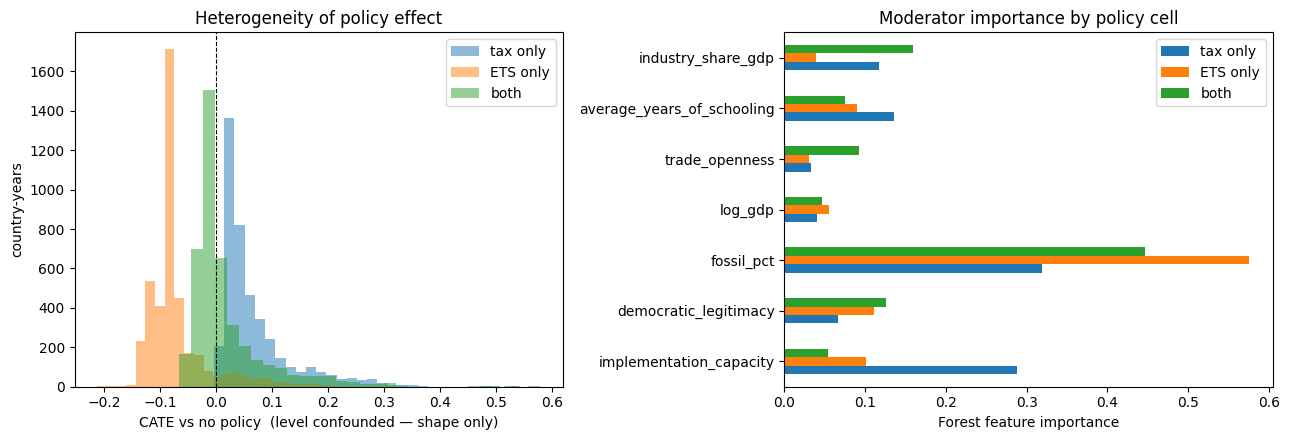


Top moderator per cell:
  tax only   -> fossil_pct (0.32)
  ETS only   -> fossil_pct (0.58)
  both       -> fossil_pct (0.45)


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for t, name in cells.items():
    axes[0].hist(dr.effect(X, T0=0, T1=t), bins=30, alpha=0.5, label=name)
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xlabel('CATE vs no policy  (level confounded — shape only)')
axes[0].set_ylabel('country-years')
axes[0].set_title('Heterogeneity of policy effect')
axes[0].legend()

imp = pd.DataFrame({name: dr.feature_importances_(T=t) for t, name in cells.items()},
                   index=[c.replace('_filled', '').replace('_z', '') for c in X_cols])
imp.plot.barh(ax=axes[1])
axes[1].set_title('Moderator importance by policy cell')
axes[1].set_xlabel('Forest feature importance')
plt.tight_layout()
plt.savefig('../outputs/drlearner_heterogeneity.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop moderator per cell:")
for name in cells.values():
    print(f"  {name:10} -> {imp[name].idxmax()} ({imp[name].max():.2f})")

### ForestDRLearner findings

**Levels (anchored, parametric within-FE):** ETS-only −0.14 (p≈0.05) and both −0.14 (p≈0.08) carry the reduction; tax-only −0.07 (p≈0.06) is weaker — the same "ETS does the work, the tax is marginal" story as §1, now confirmed under a clean 4-cell categorical specification. The forest's own ATEs sit near zero with very wide intervals (small treated cells + no country FE), which is exactly why we read the forest for *shape*, not magnitude.

**Heterogeneity (the forest's job):** effects vary materially across countries (CATE sd ≈ 0.13–0.16 around each cell). The dominant moderator is **implementation capacity** for every cell (importance ≈ 0.33 for *both*), with schooling and industry share next. Notably, **fossil share carries ~zero importance in the *both* cell** even though it significantly dampens the tax effect in §1's parametric heterogeneity — consistent with fossil-dependence mattering for the *tax* margin specifically, not for the combined-policy contrast.

**Takeaway for Phase 3:** the recommendation engine should treat **implementation capacity as the primary effect modifier** and keep policy magnitudes anchored to the within-FE parametric estimates, not the forest levels. This closes Phase 2; the clean causal questions were already answered parametrically, and the DR-learner adds the nonlinear heterogeneity map (and the DR-learner method itself) on top.